In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# ! wget --no-check-certificate https://iaifi.org/images/iaifi-logo-black-noborder-hires.jpg

In [3]:
image = Image.open('../data/iaifi-logo-black-noborder-hires.jpg').convert('L')
data = np.asarray(image)

In [4]:
dist_true = ~data[::-1]
dist_true = dist_true / np.sum(dist_true)

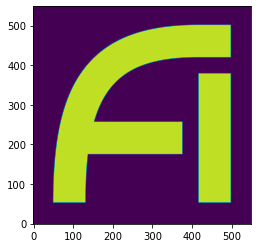

In [5]:
plt.imshow(dist_true, origin='lower')

In [6]:
pairs = np.indices(dimensions=dist_true.shape).T

n = 5000
inds=np.random.choice(np.arange(np.prod(dist_true.shape)),p=dist_true.reshape(-1),size=n,replace=True)

selections = pairs.reshape(-1,2)[inds].astype(np.float32)

In [7]:
selections_std = selections.std()
selections_mean = selections.mean()

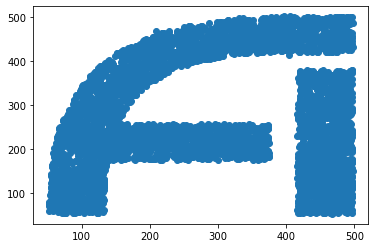

In [8]:
plt.scatter(*selections.T)

## Pyro

In [10]:
def sample_data(batch_size=200):
    """data and rng are ignored."""
    pairs = np.indices(dimensions=dist_true.shape).T
    inds=np.random.choice(np.arange(np.prod(dist_true.shape)),p=dist_true.reshape(-1),size=batch_size,replace=True)
    samples = pairs.reshape(-1,2)[inds].astype(np.float32)
    return (samples - selections_mean) / selections_std

In [16]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import autoguide
from pyro.optim import Adam
from pyro.infer import SVI, Trace_ELBO
from tqdm import tqdm

In [12]:
input_dim = 2 
n_flows = 12  # Number of flow transformations to be chained

# Base distribution
dist_z = dist.Normal(torch.zeros(input_dim), torch.ones(input_dim))

# Defines the Transformation 
# T = [pyro.distributions.transforms.affine_autoregressive(input_dim=input_dim, hidden_dims=[64, 64]) for _ in range(n_flows)]
T = [pyro.distributions.transforms.spline_autoregressive(input_dim=input_dim, hidden_dims=[128, 128]) for _ in range(n_flows)]

# Creates a distribution object which is Z transformed with the transformation T 
dist_theta = dist.TransformedDistribution(dist_z, T)

In [13]:
params = []
param_count = 0

for T_i in T:
    params += list(T_i.parameters())
    
    for param in T_i.parameters():
        param_count += len(param)
    
print("The flow transformation has {} parameters".format(param_count))

The flow transformation has 7632 parameters


In [14]:
x = torch.Tensor(sample_data(1000000).astype(np.float32))

In [15]:
def train_flow(dataset, params, batch_size=256, n_steps=2501, lr = 5e-4):
    """ Convenience function for training the normalizing flow transformation
    """
    dataset = torch.tensor(dataset)
    optimizer = torch.optim.Adam(params, lr=lr)
    
    # Run specified number of optimization steps
    for i_step in tqdm(range(n_steps)):
        
        optimizer.zero_grad()
        
        # Draw random batches and compute their log-probability
        idxs = np.random.choice(dataset.shape[0], batch_size) 
        loss = -dist_theta.log_prob(dataset[idxs,:]).mean()
        
        loss.backward()
        optimizer.step()
        dist_theta.clear_cache()

        if i_step % 200 == 0: print('Step: {}; Loss: {}'.format(i_step, loss.item()))

In [17]:
train_flow(x, params=params, n_steps=5000, batch_size=512, lr = 5e-4)   
train_flow(x, params=params, n_steps=2500, batch_size=512, lr = 1e-4)   

<ipython-input-15-f87766e15de5>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset = torch.tensor(dataset)
  0%|          | 1/5000 [00:00<27:12,  3.06it/s]

Step: 0; Loss: 5.671576023101807


  4%|▍         | 201/5000 [00:51<20:12,  3.96it/s]

Step: 200; Loss: 1.9263248443603516


  8%|▊         | 401/5000 [01:42<19:43,  3.89it/s]

...

 88%|████████▊ | 2201/2500 [09:03<01:14,  4.04it/s]

Step: 2200; Loss: 1.7695751190185547


 96%|█████████▌| 2401/2500 [09:52<00:24,  4.01it/s]

Step: 2400; Loss: 1.770858645439148


100%|██████████| 2500/2500 [10:17<00:00,  4.05it/s]


In [18]:
# # Draw 5000 samples from the base distribution as well as the normalizing flow
# samples_base = np.array([dist_z.sample().detach().numpy() for _ in range(12000)])
# samples_test = np.array([dist_theta.sample().detach().numpy() for _ in range(12000)])

In [19]:
# import seaborn as sns

In [20]:
cmap = 'Reds'

In [21]:
# fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(14,4))

# sns.kdeplot(x=samples_base.T[0], y=samples_base.T[1], fill=True, levels=100, cmap=cmap, thresh=0, ax=ax[0])
# ax[0].set_title("Base density")

# sns.kdeplot(x=samples_test.T[0], y=samples_test.T[1], fill=True, levels=100, cmap=cmap, thresh=0, ax=ax[1])
# ax[1].set_title("Transformed density")

# sns.kdeplot(x=x.T[0], y=x.T[1], fill=True, levels=100, cmap=cmap, thresh=0, ax=ax[2])
# ax[2].set_title("True (target) density")

# [ax[i].set_xlim(-1.5, 1.5) for i in range(3)]
# [ax[i].set_ylim(-1.5, 1.5) for i in range(3)]

In [22]:
import matplotlib.colors

norm = plt.Normalize(0, 0.5)
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white","firebrick"])

<ipython-input-23-f287d8f46171>:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:210.)
  ax[i].imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).sum(-1).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, norm=norm, extent=[-extent, extent, -extent, extent])


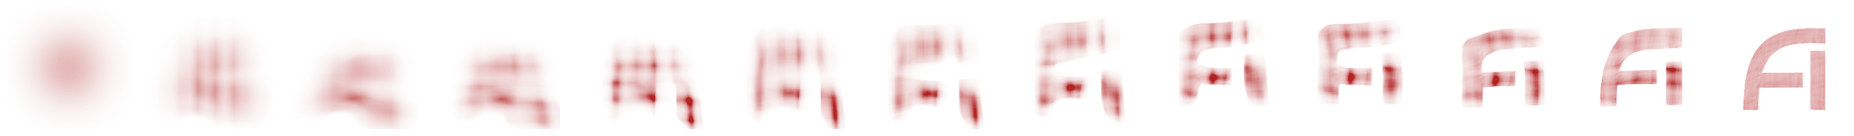

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=n_flows + 1, figsize=(26,2))
extent = 2.5

bins = 200
x_lin = np.linspace(-extent, extent, bins)
xx, yy = np.meshgrid(x_lin, x_lin)
for i in range(0, n_flows + 1):
    
    if i == 0:
        dist_test = dist.TransformedDistribution(dist_z, [T[j] for j in range(i)])
        ax[i].imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).sum(-1).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, norm=norm, extent=[-extent, extent, -extent, extent])
    else:
        dist_test = dist.TransformedDistribution(dist_z, [T[j] for j in range(i)])
        ax[i].imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, norm=norm, extent=[-extent, extent, -extent, extent])
    
    # if i == 0:
    #     ax[i].set_title("Base density")
    # else:
    #     ax[i].set_title(r"$T_{{}} \circ\ldots$".format(i))
        
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)
    ax[i].axis("off")

[ax[i].set_xlim(-extent, extent) for i in range(n_flows + 1)];
[ax[i].set_ylim(-extent, extent) for i in range(n_flows + 1)];

plt.tight_layout()
# plt.savefig("log_prob_red.pdf")

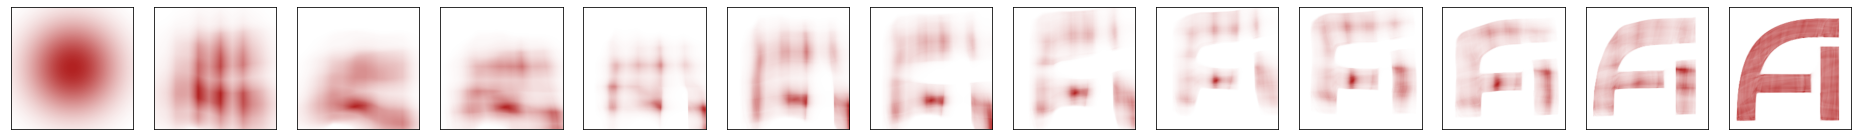

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=n_flows + 1, figsize=(26,2))
extent = 2

bins = 200
x_lin = np.linspace(-extent, extent, bins)
xx, yy = np.meshgrid(x_lin, x_lin)
for i in range(0, n_flows + 1):
    
    if i == 0:
        dist_test = dist.TransformedDistribution(dist_z, [T[j] for j in range(i)])
        ax[i].imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).sum(-1).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, extent=[-extent, extent, -extent, extent])
    else:
        dist_test = dist.TransformedDistribution(dist_z, [T[j] for j in range(i)])
        ax[i].imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, extent=[-extent, extent, -extent, extent])
    
    # if i == 0:
    #     ax[i].set_title("Base density")
    # else:
    #     ax[i].set_title(r"$T_{{}} \circ\ldots$".format(i))
        
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)

[ax[i].set_xlim(-extent, extent) for i in range(n_flows + 1)];
[ax[i].set_ylim(-extent, extent) for i in range(n_flows + 1)];

plt.tight_layout()
# plt.savefig("log_prob.pdf")

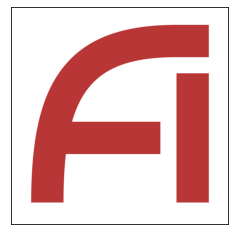

In [25]:
plt.imshow(dist_true, origin='lower', cmap=cmap)
plt.gca().get_xaxis().set_visible(False)
plt.gca().get_yaxis().set_visible(False)
# plt.savefig("density.pdf")

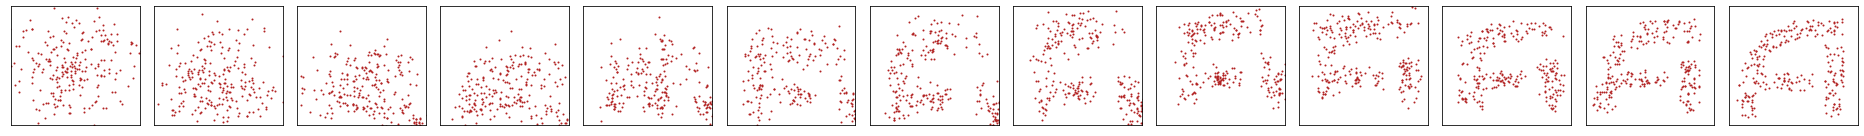

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=n_flows + 1, figsize=(26,2))

for i in range(n_flows + 1):
    
    dist_test = dist.TransformedDistribution(dist_z, [T[j] for j in range(i)])

    samples_test = np.array([dist_test.sample().detach().numpy() for _ in range(250)])
    ax[i].scatter(*samples_test.T, s=1, color='firebrick')
    
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)

[ax[i].set_xlim(-extent, extent) for i in range(n_flows + 1)];
[ax[i].set_ylim(-extent, extent) for i in range(n_flows + 1)];

plt.tight_layout()
# plt.savefig("samples.pdf")

## Latent space tests

(-3.0, 3.0)

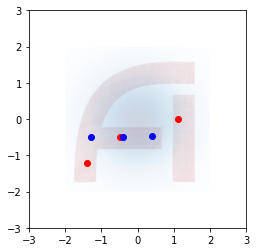

In [244]:
z = torch.Tensor([[1.1, 0,], [-1.4, -1.2], [-0.5, -0.5]])
# z = torch.Tensor([[0, 0,], [0, 0.1], [-0.5, -0.5]])

plt.scatter(*z.detach().numpy().T, color='red')

for i in np.arange(n_flows)[::-1]:
    z = dist_test.transforms[i].inv(z)
    
plt.scatter(*z.detach().numpy().T, color='blue')

plt.imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, extent=[-extent, extent, -extent, extent], alpha=0.2)
plt.imshow(np.e ** dist_z.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).sum(-1).reshape(bins, bins).detach().numpy(), origin='lower', cmap='Blues', extent=[-extent, extent, -extent, extent], alpha=0.2)

plt.xlim(-3, 3)
plt.ylim(-3, 3)

In [245]:
def z_interpolate(z1_list, z2_list, weight=0.5):
    z_interp_list = [torch.lerp(z1, z2, weight) for z1, z2 in zip(z1_list, z2_list)]
    return z_interp_list

In [246]:
# z = torch.Tensor([[1.1, 0.], [0., 1.2]])
# for i in range(2)[::-1]:
#     z = dist_test.transforms[i].inv(z)
# for i in range(2):
#     z = dist_test.transforms[i](z)
# print(z)

In [250]:
from celluloid import Camera

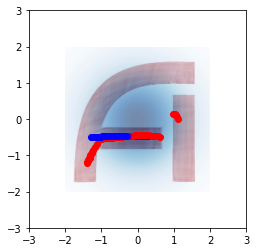

In [255]:
fig = plt.figure()
camera = Camera(fig)

for w in np.linspace(0, 1, 50):

    plt.imshow(np.e ** dist_test.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).reshape(bins, bins).detach().numpy(), origin='lower', cmap=cmap, extent=[-extent, extent, -extent, extent], alpha=0.2)
    plt.imshow(np.e ** dist_z.log_prob(torch.Tensor([xx, yy]).reshape(2, bins * bins).T).sum(-1).reshape(bins, bins).detach().numpy(), origin='lower', cmap='Blues', extent=[-extent, extent, -extent, extent], alpha=0.2)

    z_interp = torch.Tensor([z_interpolate(z[0], z[1], w)])
    plt.scatter(*z_interp.detach().numpy().T, color='blue')

    for i in np.arange(n_flows):
        z_interp = dist_test.transforms[i](z_interp)

    plt.scatter(*z_interp.detach().numpy().T, color='red')

    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    
    camera.snap()

In [256]:
animation = camera.animate()
animation.save('animation.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.
